In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

In [40]:
pima = pd.read_csv("PIMA diabetes dataset_A.csv")


In [41]:
print("PIMA dataset shape",pima.shape)



PIMA dataset shape (768, 9)


In [42]:

print("Pima first 5 rows:")
display(pima.head())



Pima first 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [43]:
print("Pima info:")
pima.info()



Pima info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [44]:

print("Missing values in Pima:")
display(pima.isnull().sum())


Missing values in Pima:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [45]:

invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in invalid_zero_cols:
    if col in pima.columns:
        print(f"{col}: {(pima[col] == 0).sum()} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


In [46]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

pima[invalid_zero_cols] = imputer.fit_transform(pima[invalid_zero_cols])

In [47]:
print(pima[invalid_zero_cols].isnull().sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [48]:
# For Pima, target is usually called Outcome
print("Pima target distribution:")
display(pima["Outcome"].value_counts())
display(pima["Outcome"].value_counts(normalize=True) * 100)


Pima target distribution:


Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

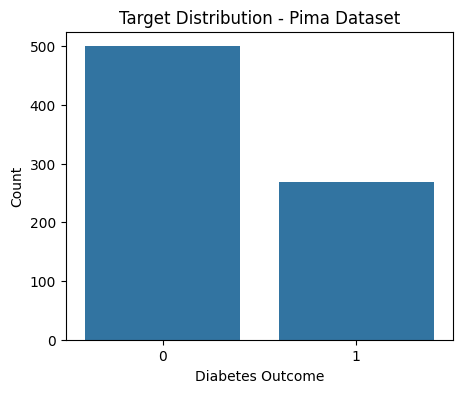

In [49]:


plt.figure(figsize=(5,4))
sns.countplot(data=pima, x="Outcome")
plt.title("Target Distribution - Pima Dataset")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Count")
plt.show()


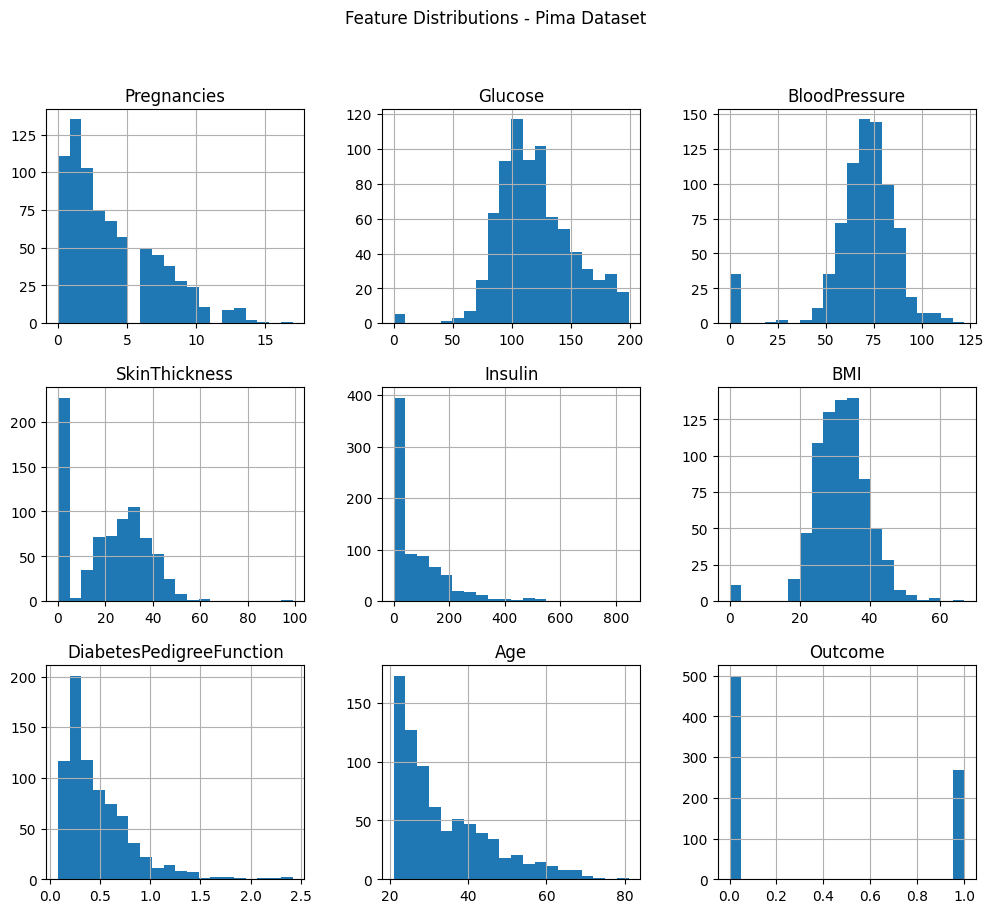

In [50]:


pima.hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature Distributions - Pima Dataset")
plt.show()

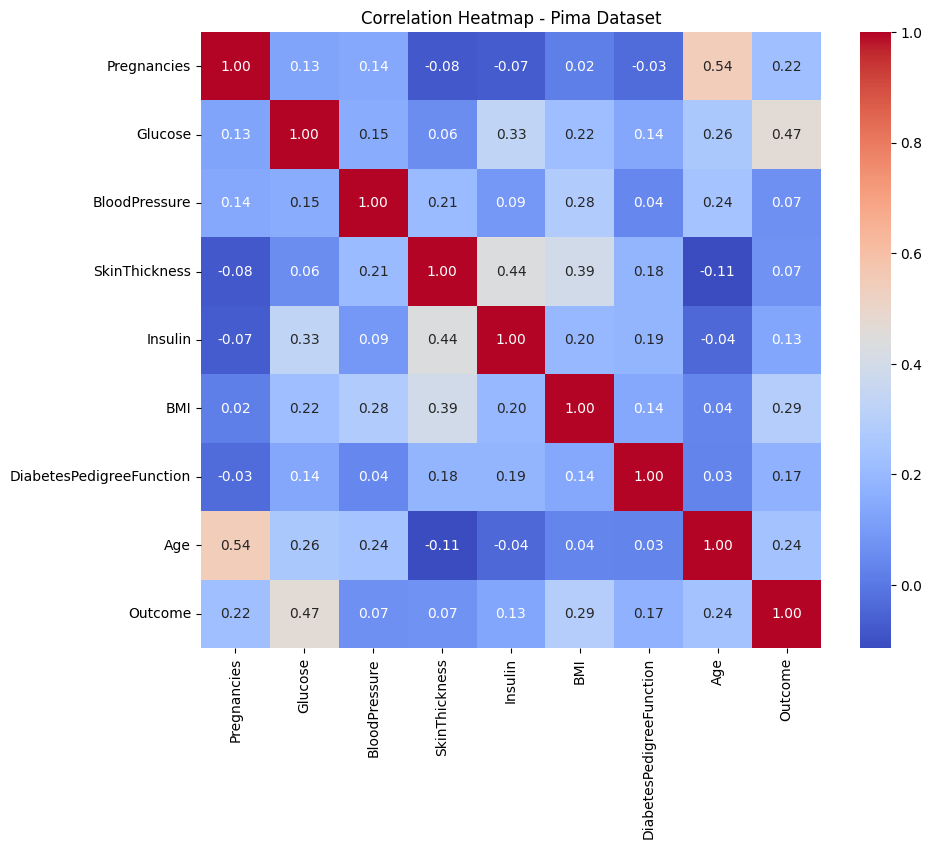

In [51]:

plt.figure(figsize=(10, 8))
sns.heatmap(pima.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Pima Dataset")
plt.show()

In [52]:


summary_table = pd.DataFrame({
    "Dataset": ["Pima Indians Diabetes Dataset"],
    "Samples": [pima.shape[0]],
    "Columns": [pima.shape[1]],
    "Target Variable": ["Outcome"],
    "Feature Type": ["Mostly numerical clinical measurements"]
})

display(summary_table)

,Dataset,Samples,Columns,Target Variable,Feature Type
0,Pima Indians Diabetes Dataset,768,9,Outcome,Mostly numerical clinical measurements


In [53]:
# ============================================================
# 15. CREATE DATASET COMPARISON TABLE
# ============================================================

comparison_table = pd.DataFrame({
    "Aspect": [
        "Main purpose",
        "Feature type",
        "Clinical information type",
        "Target variable",
        "Use in this project"
    ],
    "Pima Dataset": [
        "Diabetes prediction",
        "Numerical",
        "Physiological measurements such as glucose, BMI, insulin, age",
        "Outcome",
        "Main training and internal validation dataset"
    ],
   
})

display(comparison_table)

,Aspect,Pima Dataset
0,Main purpose,Diabetes prediction
1,Feature type,Numerical
2,Clinical information type,"Physiological measurements such as glucose, BM..."
3,Target variable,Outcome
4,Use in this project,Main training and internal validation dataset


In [54]:


summary_table.to_csv("results/dataset_summary_table.csv", index=False)
comparison_table.to_csv("results/dataset_comparison_table.csv", index=False)

print("Tables saved successfully.")

Tables saved successfully.


In [55]:


with open("results/initial_dataset_report.txt", "w") as f:
    f.write("Initial Dataset Exploration Report\n")
    f.write("=================================\n\n")
    
    f.write(f"Pima Dataset Shape: {pima.shape}\n")
    f.write(f"Pima Columns: {pima.columns.tolist()}\n\n")
    

    f.write("Missing Values - Pima:\n")
    f.write(str(pima.isnull().sum()))
    f.write("\n\n")
    
    
    f.write("Invalid Zero Values in Pima:\n")
    for col in invalid_zero_cols:
        if col in pima.columns:
            f.write(f"{col}: {(pima[col] == 0).sum()} zero values\n")
    
    f.write("\nPima Target Distribution:\n")
    f.write(str(pima["Outcome"].value_counts()))
    

print("Initial report saved successfully.")

Initial report saved successfully.


In [56]:
# Features
X = pima.drop("Outcome", axis=1)

# Target
y = pima["Outcome"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (768, 8)
Target: (768,)


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (614, 8)
Testing set: (154, 8)


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

In [60]:

log_reg = LogisticRegression(random_state=42)


log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [61]:
y_pred_lr = log_reg.predict(X_test_scaled)

y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [62]:
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)
brier = brier_score_loss(y_test, y_prob_lr)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Brier    : {brier:.4f}")

Accuracy : 0.7143
Precision: 0.6087
Recall   : 0.5185
F1 Score : 0.5600
ROC-AUC  : 0.8230
Brier    : 0.1679


In [63]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



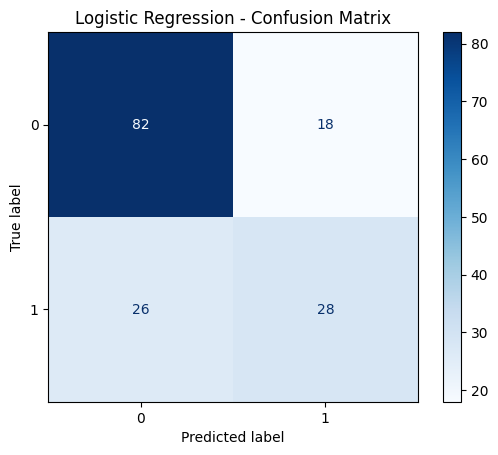

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [65]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "Brier Score": brier
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7142857142857143,
 'Precision': 0.6086956521739131,
 'Recall': 0.5185185185185185,
 'F1 Score': 0.56,
 'ROC-AUC': 0.8229629629629629,
 'Brier Score': 0.16793272823586033}

In [66]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)


rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
# Predicted labels
y_pred_rf = rf.predict(X_test)

# Predicted probabilities
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [68]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)
brier = brier_score_loss(y_test, y_prob_rf)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Brier    : {brier:.4f}")

Accuracy : 0.7597
Precision: 0.6809
Recall   : 0.5926
F1 Score : 0.6337
ROC-AUC  : 0.8118
Brier    : 0.1656


In [69]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



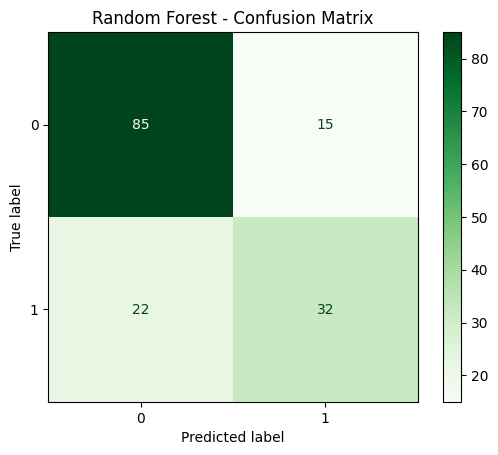

In [70]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Greens"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [71]:
random_forest_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "Brier Score": brier
}

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.7597402597402597,
 'Precision': 0.6808510638297872,
 'Recall': 0.5925925925925926,
 'F1 Score': 0.6336633663366337,
 'ROC-AUC': 0.8117592592592593,
 'Brier Score': 0.16563246753246755}

In [72]:

# XGBoost Baseline Model

from xgboost import XGBClassifier


xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)


xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [73]:
# Predictions

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [74]:
# Evaluation metrics

accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_prob_xgb)
brier = brier_score_loss(y_test, y_prob_xgb)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Brier    : {brier:.4f}")

Accuracy : 0.7338
Precision: 0.6226
Recall   : 0.6111
F1 Score : 0.6168
ROC-AUC  : 0.8052
Brier    : 0.2025


In [75]:


print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.79      0.80      0.80       100
           1       0.62      0.61      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



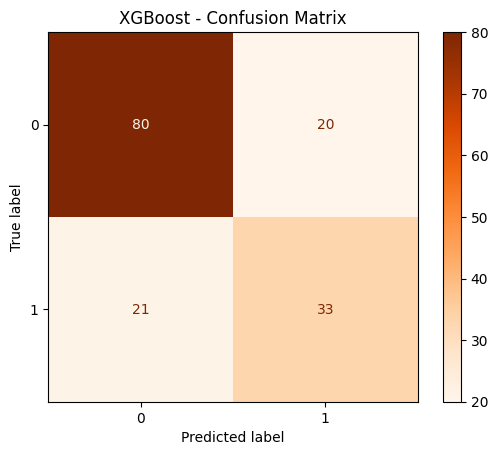

In [76]:


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Oranges"
)

plt.title("XGBoost - Confusion Matrix")
plt.show()

In [77]:
# Save results

xgboost_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc,
    "Brier Score": brier
}

xgboost_results

{'Model': 'XGBoost',
 'Accuracy': 0.7337662337662337,
 'Precision': 0.6226415094339622,
 'Recall': 0.6111111111111112,
 'F1 Score': 0.616822429906542,
 'ROC-AUC': 0.8051851851851852,
 'Brier Score': 0.20254903334756255}

In [78]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [79]:
log_reg_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

log_reg_grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=log_reg_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

log_reg_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", log_reg_grid.best_params_)
print("Best CV F1 Score:", log_reg_grid.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 Score: 0.6847622987454397


In [80]:
log_reg_param_grid_2 = {
    "C": [0.03, 0.05, 0.07, 0.1, 0.2, 0.3, 0.5],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": ["balanced"]
}
log_reg_grid_2 = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=log_reg_param_grid_2,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

log_reg_grid_2.fit(X_train_scaled, y_train)

print("Best Parameters:", log_reg_grid_2.best_params_)
print("Best CV F1 Score:", log_reg_grid_2.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 Score: 0.6847622987454397


In [81]:
best_log_reg = log_reg_grid.best_estimator_

y_pred_lr_tuned = best_log_reg.predict(X_test_scaled)
y_prob_lr_tuned = best_log_reg.predict_proba(X_test_scaled)[:, 1]

print("Tuned Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, y_pred_lr_tuned))
print("Precision:", precision_score(y_test, y_pred_lr_tuned))
print("Recall   :", recall_score(y_test, y_pred_lr_tuned))
print("F1 Score :", f1_score(y_test, y_pred_lr_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr_tuned))
print("Brier    :", brier_score_loss(y_test, y_prob_lr_tuned))

Tuned Logistic Regression Results
Accuracy : 0.7402597402597403
Precision: 0.609375
Recall   : 0.7222222222222222
F1 Score : 0.6610169491525424
ROC-AUC  : 0.8211111111111111
Brier    : 0.17527454123060238


In [82]:

rf_param_grid_2 = {
    "n_estimators": [150, 200, 250, 300, 400],
    "max_depth": [4, 5, 6, 7, 8],
    "min_samples_split": [6, 8, 10, 12, 15],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced"]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid_2,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1 Score:", rf_grid.best_score_)

Best Parameters: {'class_weight': 'balanced', 'max_depth': 7, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 150}
Best CV F1 Score: 0.6982474456490737


In [83]:
best_rf = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall   :", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score :", f1_score(y_test, y_pred_rf_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf_tuned))
print("Brier    :", brier_score_loss(y_test, y_prob_rf_tuned))

Tuned Random Forest Results
Accuracy : 0.7532467532467533
Precision: 0.6333333333333333
Recall   : 0.7037037037037037
F1 Score : 0.6666666666666666
ROC-AUC  : 0.8318518518518518
Brier    : 0.16071059822731446


In [84]:
xgb_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV F1 Score:", xgb_grid.best_score_)

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
Best CV F1 Score: 0.6535105763232648


In [85]:
best_xgb = xgb_grid.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Results")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision:", precision_score(y_test, y_pred_xgb_tuned))
print("Recall   :", recall_score(y_test, y_pred_xgb_tuned))
print("F1 Score :", f1_score(y_test, y_pred_xgb_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb_tuned))
print("Brier    :", brier_score_loss(y_test, y_prob_xgb_tuned))

Tuned XGBoost Results
Accuracy : 0.7402597402597403
Precision: 0.6458333333333334
Recall   : 0.5740740740740741
F1 Score : 0.6078431372549019
ROC-AUC  : 0.8231481481481482
Brier    : 0.16440348165131863


In [88]:
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer

In [89]:
feature_names = X_train.columns.tolist()


X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_names,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_names,
    index=X_test.index
)

# Raw/unscaled data used by Random Forest and XGBoost
X_train_df = X_train.copy()
X_test_df = X_test.copy()

print(feature_names)

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [90]:
def get_positive_class_shap_values(shap_output):


    values = (
        shap_output.values
        if hasattr(shap_output, "values")
        else shap_output
    )

   
    # [values_for_class_0, values_for_class_1]
    if isinstance(values, list):
        return np.asarray(values[1])

    values = np.asarray(values)

    
    if values.ndim == 3:
        return values[:, :, 1]

    if values.ndim == 2:
        return values

    raise ValueError(f"Unexpected SHAP output shape: {values.shape}")

In [91]:
# Background data for Logistic Regression
lr_background = shap.sample(
    X_train_scaled_df,
    100,
    random_state=42
)


shap_explainer_lr = shap.LinearExplainer(
    best_log_reg,
    lr_background
)

# Explain all test instances
shap_output_lr = shap_explainer_lr(X_test_scaled_df)

# Extract attribution matrix
shap_values_lr = get_positive_class_shap_values(shap_output_lr)

print("Logistic Regression SHAP shape:", shap_values_lr.shape)

Logistic Regression SHAP shape: (154, 8)


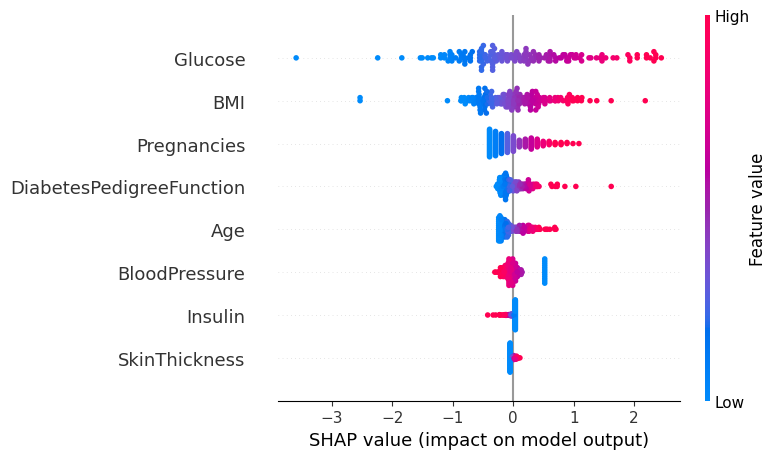

In [92]:
shap.summary_plot(
    shap_values_lr,
    X_test_scaled_df,
    feature_names=feature_names,
    show=True
)

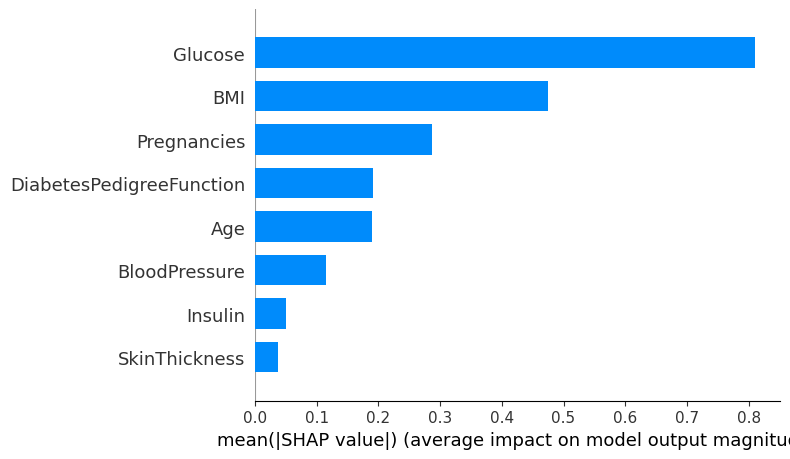

In [93]:
shap.summary_plot(
    shap_values_lr,
    X_test_scaled_df,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

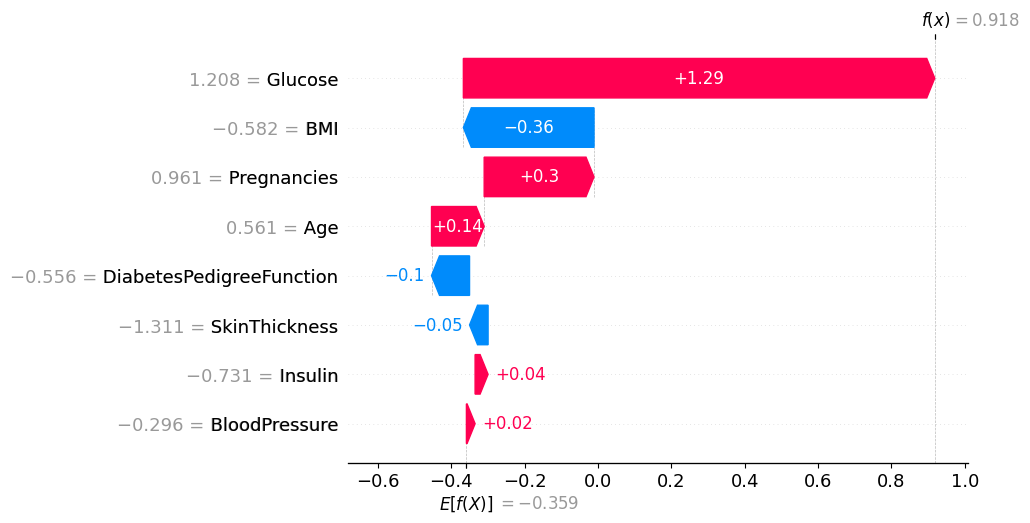

In [94]:
patient_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_lr[patient_index],
        base_values=np.asarray(shap_output_lr.base_values).reshape(-1)[patient_index]
        if np.asarray(shap_output_lr.base_values).size > 1
        else np.asarray(shap_output_lr.base_values).item(),
        data=X_test_scaled_df.iloc[patient_index].values,
        feature_names=feature_names
    ),
    max_display=8
)

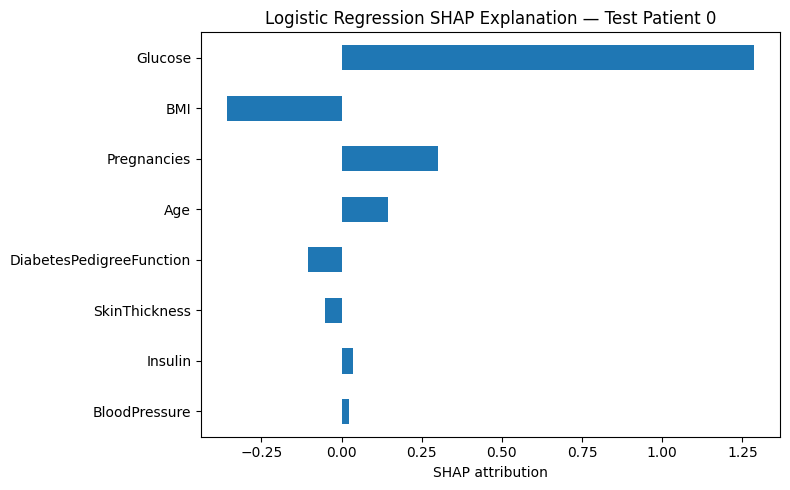

In [95]:
patient_index = 0

local_lr = pd.Series(
    shap_values_lr[patient_index],
    index=feature_names
).sort_values(key=np.abs)

local_lr.plot(kind="barh", figsize=(8, 5))
plt.title("Logistic Regression SHAP Explanation — Test Patient 0")
plt.xlabel("SHAP attribution")
plt.tight_layout()
plt.show()

In [96]:
shap_explainer_rf = shap.TreeExplainer(best_rf)

shap_output_rf = shap_explainer_rf(X_test_df)

shap_values_rf = get_positive_class_shap_values(shap_output_rf)

print("Random Forest SHAP shape:", shap_values_rf.shape)

Random Forest SHAP shape: (154, 8)


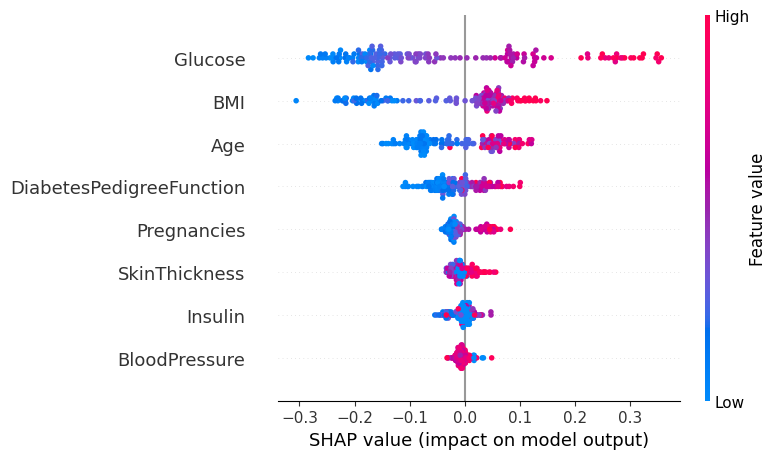

In [97]:
shap.summary_plot(
    shap_values_rf,
    X_test_df,
    feature_names=feature_names,
    show=True
)

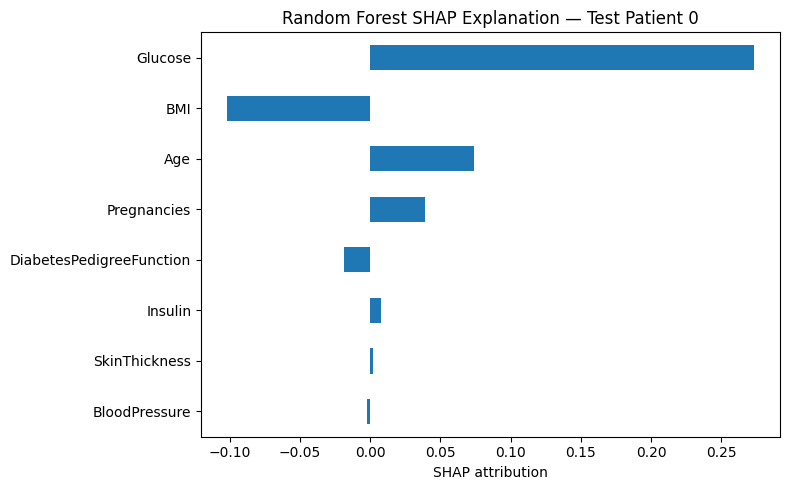

In [98]:
patient_index = 0

local_rf = pd.Series(
    shap_values_rf[patient_index],
    index=feature_names
).sort_values(key=np.abs)

local_rf.plot(kind="barh", figsize=(8, 5))
plt.title("Random Forest SHAP Explanation — Test Patient 0")
plt.xlabel("SHAP attribution")
plt.tight_layout()
plt.show()

In [102]:
import xgboost as xgb
import numpy as np
import pandas as pd

# Convert test data into XGBoost's native DMatrix format
xgb_test_matrix = xgb.DMatrix(
    X_test_df,
    feature_names=feature_names
)

# Get SHAP contributions directly from XGBoost
xgb_contributions = best_xgb.get_booster().predict(
    xgb_test_matrix,
    pred_contribs=True
)

print("Raw contribution shape:", xgb_contributions.shape)

Raw contribution shape: (154, 9)


In [103]:
shap_values_xgb = xgb_contributions[:, :-1]
xgb_base_values = xgb_contributions[:, -1]

print("XGBoost SHAP values shape:", shap_values_xgb.shape)
print("XGBoost base values shape:", xgb_base_values.shape)

XGBoost SHAP values shape: (154, 8)
XGBoost base values shape: (154,)


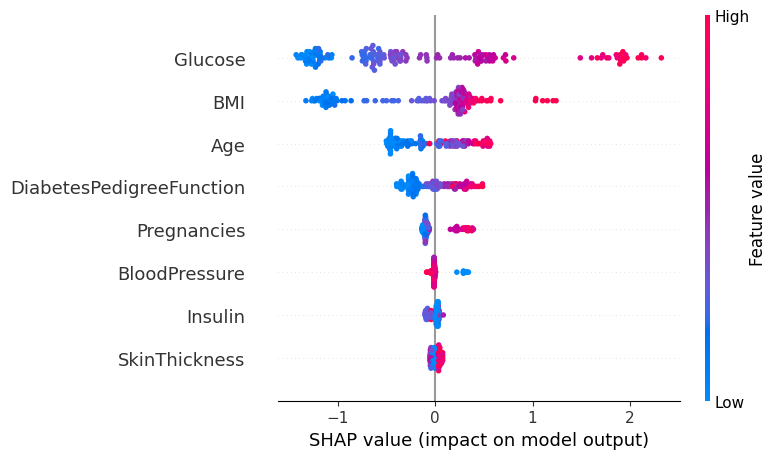

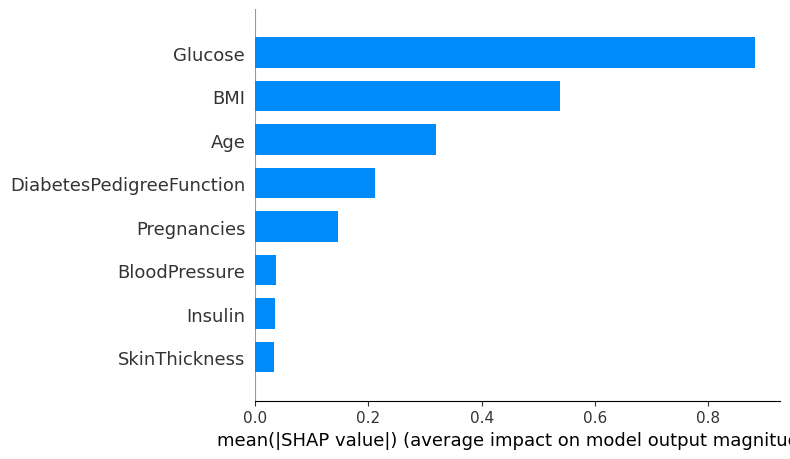

In [104]:
shap.summary_plot(
    shap_values_xgb,
    X_test_df,
    feature_names=feature_names
)
shap.summary_plot(
    shap_values_xgb,
    X_test_df,
    feature_names=feature_names,
    plot_type="bar"
)

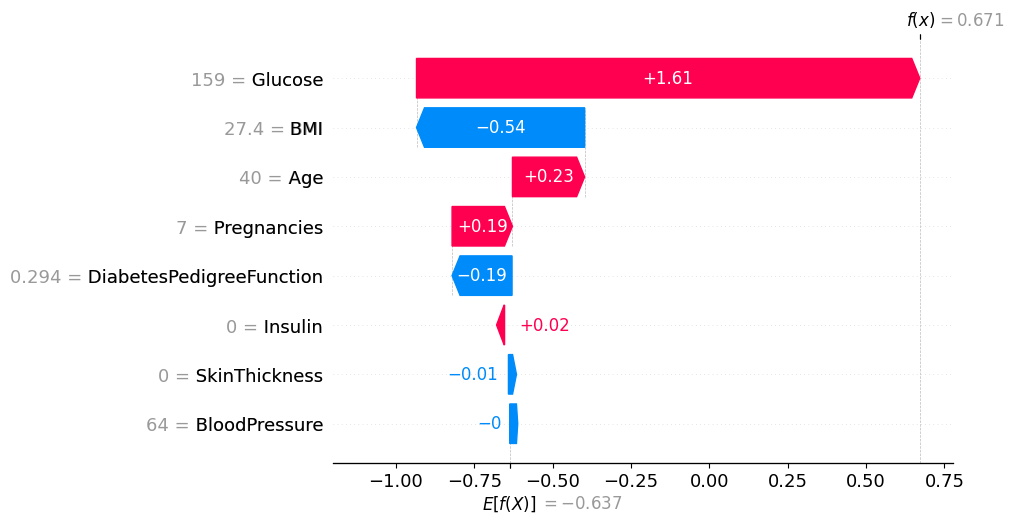

In [105]:
patient_index = 0

xgb_local_explanation = shap.Explanation(
    values=shap_values_xgb[patient_index],
    base_values=xgb_base_values[patient_index],
    data=X_test_df.iloc[patient_index].values,
    feature_names=feature_names
)

shap.plots.waterfall(
    xgb_local_explanation,
    max_display=8
)

In [106]:
lime_explainer_lr = LimeTabularExplainer(
    training_data=X_train_scaled_df.values,
    feature_names=feature_names,
    class_names=["Non-diabetic", "Diabetic"],
    mode="classification",
    discretize_continuous=False,
    random_state=42
)

In [107]:
lime_explainer_tree = LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=feature_names,
    class_names=["Non-diabetic", "Diabetic"],
    mode="classification",
    discretize_continuous=False,
    random_state=42
)

In [108]:
patient_index = 0

lime_exp_lr = lime_explainer_lr.explain_instance(
    data_row=X_test_scaled_df.iloc[patient_index].values,
    predict_fn=best_log_reg.predict_proba,
    labels=(1,),
    num_features=len(feature_names),
    num_samples=5000
)

print("Logistic Regression LIME explanation:")
print(lime_exp_lr.as_list(label=1))

Logistic Regression LIME explanation:
[('Glucose', 0.19096308220744154), ('BMI', 0.12386196787929366), ('Pregnancies', 0.06450138216108917), ('DiabetesPedigreeFunction', 0.05307943503754363), ('Age', 0.04702120095668097), ('BloodPressure', -0.028743317080017546), ('Insulin', -0.011355015057583523), ('SkinThickness', 0.007482472364011907)]


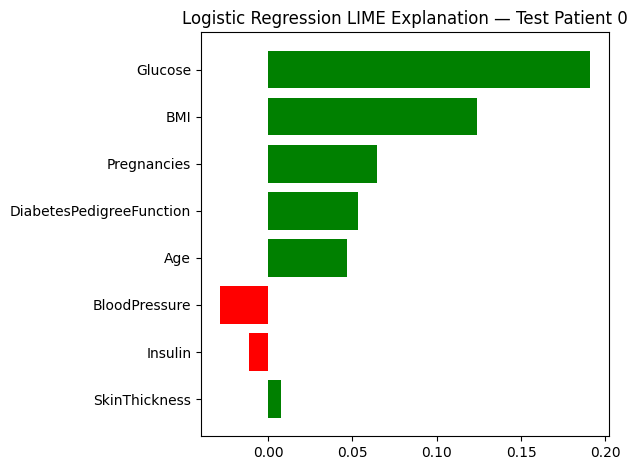

In [109]:
lime_exp_lr.as_pyplot_figure(label=1)
plt.title("Logistic Regression LIME Explanation — Test Patient 0")
plt.tight_layout()
plt.show()

In [110]:
patient_index = 0

lime_exp_rf = lime_explainer_tree.explain_instance(
    data_row=X_test_df.iloc[patient_index].values,
    predict_fn=best_rf.predict_proba,
    labels=(1,),
    num_features=len(feature_names),
    num_samples=5000
)

print("Random Forest LIME explanation:")
print(lime_exp_rf.as_list(label=1))

Random Forest LIME explanation:
[('Glucose', 0.1726803479217416), ('BMI', 0.10987687134106759), ('Age', 0.056937508056539236), ('DiabetesPedigreeFunction', 0.04303237552368913), ('Pregnancies', 0.024558545857534232), ('BloodPressure', 0.00399441309508901), ('SkinThickness', 0.0032475046145409173), ('Insulin', -0.0019522364816146073)]


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


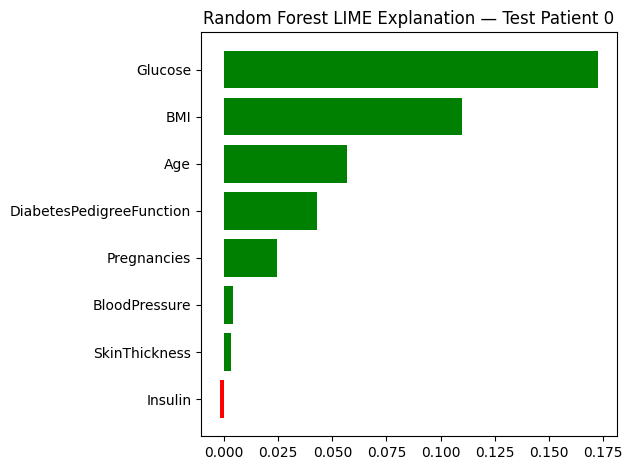

In [111]:
lime_exp_rf.as_pyplot_figure(label=1)
plt.title("Random Forest LIME Explanation — Test Patient 0")
plt.tight_layout()
plt.show()

In [112]:
patient_index = 0

lime_exp_xgb = lime_explainer_tree.explain_instance(
    data_row=X_test_df.iloc[patient_index].values,
    predict_fn=best_xgb.predict_proba,
    labels=(1,),
    num_features=len(feature_names),
    num_samples=5000
)

print("XGBoost LIME explanation:")
print(lime_exp_xgb.as_list(label=1))

XGBoost LIME explanation:
[('Glucose', 0.19269736195729345), ('BMI', 0.11480075452604785), ('Age', 0.05098173918822342), ('DiabetesPedigreeFunction', 0.04514950300419125), ('Pregnancies', 0.026628692979373356), ('BloodPressure', -0.010430134935794191), ('Insulin', -0.0022836537546962717), ('SkinThickness', -0.0008300428503779993)]


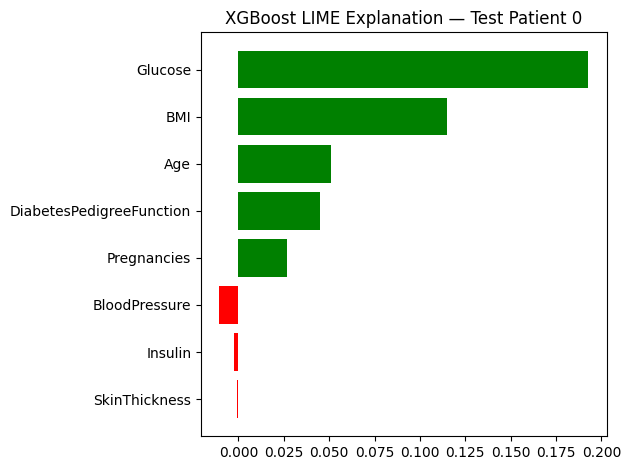

In [113]:
lime_exp_xgb.as_pyplot_figure(label=1)
plt.title("XGBoost LIME Explanation — Test Patient 0")
plt.tight_layout()
plt.show()

In [114]:
def lime_explanation_to_vector(explanation, n_features, label=1):
   

    vector = np.zeros(n_features, dtype=float)

    explanation_map = explanation.as_map()

    if label not in explanation_map:
        raise KeyError(
            f"Label {label} not found. Available labels: "
            f"{list(explanation_map.keys())}"
        )

    for feature_index, weight in explanation_map[label]:
        vector[feature_index] = weight

    return vector

In [115]:
def generate_lime_matrix(
    explainer,
    model,
    X_data,
    n_features,
    label=1,
    num_samples=5000
):
    

    lime_matrix = np.zeros(
        (len(X_data), n_features),
        dtype=float
    )

    for row_position in range(len(X_data)):
        explanation = explainer.explain_instance(
            data_row=X_data.iloc[row_position].values,
            predict_fn=model.predict_proba,
            labels=(label,),
            num_features=n_features,
            num_samples=num_samples
        )

        lime_matrix[row_position] = lime_explanation_to_vector(
            explanation=explanation,
            n_features=n_features,
            label=label
        )

        if (row_position + 1) % 20 == 0:
            print(
                f"Completed {row_position + 1}/{len(X_data)} explanations"
            )

    return lime_matrix

In [116]:
lime_values_lr = generate_lime_matrix(
    explainer=lime_explainer_lr,
    model=best_log_reg,
    X_data=X_test_scaled_df,
    n_features=len(feature_names),
    label=1,
    num_samples=5000
)

print("LR LIME matrix shape:", lime_values_lr.shape)

Completed 20/154 explanations
Completed 40/154 explanations
Completed 60/154 explanations
Completed 80/154 explanations
Completed 100/154 explanations
Completed 120/154 explanations
Completed 140/154 explanations
LR LIME matrix shape: (154, 8)


In [117]:
lime_values_rf = generate_lime_matrix(
    explainer=lime_explainer_tree,
    model=best_rf,
    X_data=X_test_df,
    n_features=len(feature_names),
    label=1,
    num_samples=5000
)

print("RF LIME matrix shape:", lime_values_rf.shape)

C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Completed 20/154 explanations


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Completed 40/154 explanations


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Completed 60/154 explanations


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Completed 80/154 explanations


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Completed 100/154 explanations


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Completed 120/154 explanations


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Completed 140/154 explanations


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

RF LIME matrix shape: (154, 8)


In [118]:
lime_values_xgb = generate_lime_matrix(
    explainer=lime_explainer_tree,
    model=best_xgb,
    X_data=X_test_df,
    n_features=len(feature_names),
    label=1,
    num_samples=5000
)

print("XGB LIME matrix shape:", lime_values_xgb.shape)

Completed 20/154 explanations
Completed 40/154 explanations
Completed 60/154 explanations
Completed 80/154 explanations
Completed 100/154 explanations
Completed 120/154 explanations
Completed 140/154 explanations
XGB LIME matrix shape: (154, 8)


In [119]:
explanation_shapes = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "SHAP Shape": [
        str(shap_values_lr.shape),
        str(shap_values_rf.shape),
        str(shap_values_xgb.shape)
    ],
    "LIME Shape": [
        str(lime_values_lr.shape),
        str(lime_values_rf.shape),
        str(lime_values_xgb.shape)
    ]
})

display(explanation_shapes)

,Model,SHAP Shape,LIME Shape
0,Logistic Regression,"(154, 8)","(154, 8)"
1,Random Forest,"(154, 8)","(154, 8)"
2,XGBoost,"(154, 8)","(154, 8)"


In [120]:
explanation_matrices = {
    "Logistic Regression": (shap_values_lr, lime_values_lr),
    "Random Forest": (shap_values_rf, lime_values_rf),
    "XGBoost": (shap_values_xgb, lime_values_xgb)
}

for model_name, (shap_matrix, lime_matrix) in explanation_matrices.items():

    print(model_name)
    print("SHAP shape:", shap_matrix.shape)
    print("LIME shape:", lime_matrix.shape)

    assert shap_matrix.shape == lime_matrix.shape, (
        f"SHAP and LIME shapes do not match for {model_name}"
    )

    assert shap_matrix.shape[1] == len(feature_names), (
        f"Unexpected number of features for {model_name}"
    )

    assert np.isfinite(shap_matrix).all(), (
        f"SHAP contains NaN or infinite values for {model_name}"
    )

    assert np.isfinite(lime_matrix).all(), (
        f"LIME contains NaN or infinite values for {model_name}"
    )

    print("Validation passed.\n")

Logistic Regression
SHAP shape: (154, 8)
LIME shape: (154, 8)
Validation passed.

Random Forest
SHAP shape: (154, 8)
LIME shape: (154, 8)
Validation passed.

XGBoost
SHAP shape: (154, 8)
LIME shape: (154, 8)
Validation passed.



In [121]:
np.abs(shap_vector)
np.abs(lime_vector)

NameError: name 'shap_vector' is not defined

In [122]:
def calculate_spearman_agreement(shap_vector, lime_vector):
    """
    Calculate SHAP-LIME rank agreement for one patient.

    Absolute attribution values are used because this metric evaluates
    agreement in feature importance ranking.
    """

    shap_importance = np.abs(np.asarray(shap_vector, dtype=float))
    lime_importance = np.abs(np.asarray(lime_vector, dtype=float))

    correlation, p_value = spearmanr(
        shap_importance,
        lime_importance
    )

    # Spearman may be undefined if every value in one vector is identical.
    if np.isnan(correlation):
        correlation = 0.0

    return correlation, p_value

In [125]:
patient_index = 0

spearman_value, p_value = calculate_spearman_agreement(
    shap_values_lr[patient_index],
    lime_values_lr[patient_index]
)

print("Spearman correlation:", spearman_value)
print("p-value:", p_value)

Spearman correlation: 0.880952380952381
p-value: 0.0038503204637324014


In [126]:
def normalise_spearman(correlation):
    return (correlation + 1.0) / 2.0

In [127]:
normalised_value = normalise_spearman(spearman_value)

print("Original Spearman:", spearman_value)
print("Normalised Spearman:", normalised_value)

Original Spearman: 0.880952380952381
Normalised Spearman: 0.9404761904761905


In [128]:
def calculate_top_k_overlap(shap_vector, lime_vector, k=3):
    """
    Calculate the proportion of shared features in the SHAP and LIME
    top-k importance sets for one patient.
    """

    shap_importance = np.abs(np.asarray(shap_vector, dtype=float))
    lime_importance = np.abs(np.asarray(lime_vector, dtype=float))

    if not 1 <= k <= len(shap_importance):
        raise ValueError(
            f"k must be between 1 and {len(shap_importance)}"
        )

    shap_top_k = np.argsort(shap_importance)[-k:]
    lime_top_k = np.argsort(lime_importance)[-k:]

    shared_features = set(shap_top_k).intersection(set(lime_top_k))

    overlap_score = len(shared_features) / k

    return overlap_score, shap_top_k, lime_top_k

In [129]:
top_k_score, shap_top_k, lime_top_k = calculate_top_k_overlap(
    shap_values_lr[patient_index],
    lime_values_lr[patient_index],
    k=3
)

print("Top-3 overlap:", top_k_score)

print(
    "SHAP top features:",
    [feature_names[i] for i in shap_top_k[::-1]]
)

print(
    "LIME top features:",
    [feature_names[i] for i in lime_top_k[::-1]]
)

Top-3 overlap: 1.0
SHAP top features: ['Glucose', 'BMI', 'Pregnancies']
LIME top features: ['Glucose', 'BMI', 'Pregnancies']


In [130]:
def calculate_patient_agreement(
    shap_vector,
    lime_vector,
    k=3,
    spearman_weight=0.5,
    top_k_weight=0.5
):
    """
    Calculate SHAP-LIME agreement for one patient.

    Returns:
    - original Spearman correlation
    - normalised Spearman score
    - top-k overlap
    - combined agreement score
    """

    if not np.isclose(spearman_weight + top_k_weight, 1.0):
        raise ValueError("The metric weights must sum to 1.")

    spearman_raw, spearman_p = calculate_spearman_agreement(
        shap_vector,
        lime_vector
    )

    spearman_normalised = normalise_spearman(spearman_raw)

    top_k_overlap, shap_top_k, lime_top_k = calculate_top_k_overlap(
        shap_vector,
        lime_vector,
        k=k
    )

    agreement_score = (
        spearman_weight * spearman_normalised
        + top_k_weight * top_k_overlap
    )

    return {
        "spearman_raw": spearman_raw,
        "spearman_p_value": spearman_p,
        "spearman_normalised": spearman_normalised,
        "top_k_overlap": top_k_overlap,
        "agreement_score": agreement_score,
        "shap_top_k": shap_top_k,
        "lime_top_k": lime_top_k
    }

In [131]:
patient_agreement = calculate_patient_agreement(
    shap_values_lr[0],
    lime_values_lr[0],
    k=3
)

patient_agreement

{'spearman_raw': np.float64(0.880952380952381),
 'spearman_p_value': np.float64(0.0038503204637324014),
 'spearman_normalised': np.float64(0.9404761904761905),
 'top_k_overlap': 1.0,
 'agreement_score': np.float64(0.9702380952380952),
 'shap_top_k': array([0, 5, 1]),
 'lime_top_k': array([0, 5, 1])}

In [132]:
def calculate_agreement_matrix(
    shap_matrix,
    lime_matrix,
    feature_names,
    model_name,
    k=3,
    spearman_weight=0.5,
    top_k_weight=0.5
):
    """
    Calculate SHAP-LIME agreement for every test patient of one model.
    """

    shap_matrix = np.asarray(shap_matrix, dtype=float)
    lime_matrix = np.asarray(lime_matrix, dtype=float)

    if shap_matrix.shape != lime_matrix.shape:
        raise ValueError(
            f"Shape mismatch: SHAP {shap_matrix.shape}, "
            f"LIME {lime_matrix.shape}"
        )

    results = []

    for patient_position in range(shap_matrix.shape[0]):

        patient_result = calculate_patient_agreement(
            shap_vector=shap_matrix[patient_position],
            lime_vector=lime_matrix[patient_position],
            k=k,
            spearman_weight=spearman_weight,
            top_k_weight=top_k_weight
        )

        shap_top_features = [
            feature_names[i]
            for i in patient_result["shap_top_k"][::-1]
        ]

        lime_top_features = [
            feature_names[i]
            for i in patient_result["lime_top_k"][::-1]
        ]

        results.append({
            "Model": model_name,
            "Patient_Position": patient_position,
            "Original_Row_Index": X_test_df.index[patient_position],
            "Spearman_Raw": patient_result["spearman_raw"],
            "Spearman_P_Value": patient_result["spearman_p_value"],
            "Spearman_Normalised": patient_result[
                "spearman_normalised"
            ],
            f"Top_{k}_Overlap": patient_result["top_k_overlap"],
            "Agreement_Score": patient_result["agreement_score"],
            "SHAP_Top_Features": ", ".join(shap_top_features),
            "LIME_Top_Features": ", ".join(lime_top_features)
        })

    return pd.DataFrame(results)

In [133]:
agreement_lr = calculate_agreement_matrix(
    shap_matrix=shap_values_lr,
    lime_matrix=lime_values_lr,
    feature_names=feature_names,
    model_name="Logistic Regression",
    k=3
)

agreement_lr.head()

,Model,Patient_Position,Original_Row_Index,Spearman_Raw,Spearman_P_Value,Spearman_Normalised,Top_3_Overlap,Agreement_Score,SHAP_Top_Features,LIME_Top_Features
0,Logistic Regression,0,44,0.880952,0.003850,0.940476,1.000000,0.970238,"Glucose, BMI, Pregnancies","Glucose, BMI, Pregnancies"
1,Logistic Regression,1,672,0.785714,0.020815,0.892857,0.666667,0.779762,"Glucose, Pregnancies, BloodPressure","Glucose, BMI, Pregnancies"
2,Logistic Regression,2,700,0.761905,0.028005,0.880952,1.000000,0.940476,"BMI, Pregnancies, Glucose","Glucose, BMI, Pregnancies"
3,Logistic Regression,3,630,0.619048,0.101733,0.809524,0.666667,0.738095,"BMI, Pregnancies, DiabetesPedigreeFunction","Glucose, BMI, Pregnancies"
4,Logistic Regression,4,81,0.738095,0.036553,0.869048,0.666667,0.767857,"BMI, Glucose, BloodPressure","Glucose, BMI, Pregnancies"


In [134]:
agreement_rf = calculate_agreement_matrix(
    shap_matrix=shap_values_rf,
    lime_matrix=lime_values_rf,
    feature_names=feature_names,
    model_name="Random Forest",
    k=3
)

agreement_rf.head()

,Model,Patient_Position,Original_Row_Index,Spearman_Raw,Spearman_P_Value,Spearman_Normalised,Top_3_Overlap,Agreement_Score,SHAP_Top_Features,LIME_Top_Features
0,Random Forest,0,44,0.904762,0.002008,0.952381,1.000000,0.976190,"Glucose, BMI, Age","Glucose, BMI, Age"
1,Random Forest,1,672,0.476190,0.232936,0.738095,0.666667,0.702381,"Glucose, Age, Insulin","Glucose, BMI, Age"
2,Random Forest,2,700,0.857143,0.006530,0.928571,1.000000,0.964286,"Age, Glucose, BMI","Glucose, BMI, Age"
3,Random Forest,3,630,0.928571,0.000863,0.964286,1.000000,0.982143,"BMI, Glucose, Age","Glucose, BMI, Age"
4,Random Forest,4,81,0.976190,0.000033,0.988095,1.000000,0.994048,"Glucose, BMI, Age","Glucose, BMI, Age"


In [135]:
agreement_xgb = calculate_agreement_matrix(
    shap_matrix=shap_values_xgb,
    lime_matrix=lime_values_xgb,
    feature_names=feature_names,
    model_name="XGBoost",
    k=3
)

agreement_xgb.head()

,Model,Patient_Position,Original_Row_Index,Spearman_Raw,Spearman_P_Value,Spearman_Normalised,Top_3_Overlap,Agreement_Score,SHAP_Top_Features,LIME_Top_Features
0,XGBoost,0,44,0.904762,0.002008,0.952381,1.000000,0.976190,"Glucose, BMI, Age","Glucose, BMI, Age"
1,XGBoost,1,672,0.880952,0.003850,0.940476,0.666667,0.803571,"Glucose, Age, Pregnancies","Glucose, BMI, Age"
2,XGBoost,2,700,0.666667,0.070988,0.833333,1.000000,0.916667,"Glucose, Age, BMI","Glucose, BMI, Age"
3,XGBoost,3,630,0.880952,0.003850,0.940476,0.666667,0.803571,"BMI, Glucose, DiabetesPedigreeFunction","Glucose, BMI, Age"
4,XGBoost,4,81,0.976190,0.000033,0.988095,1.000000,0.994048,"Glucose, BMI, Age","Glucose, BMI, Age"


In [137]:
agreement_all = pd.concat(
    [
        agreement_lr,
        agreement_rf,
        agreement_xgb
    ],
    ignore_index=True
)

print(agreement_all.shape)
agreement_all.head()

(462, 10)


,Model,Patient_Position,Original_Row_Index,Spearman_Raw,Spearman_P_Value,Spearman_Normalised,Top_3_Overlap,Agreement_Score,SHAP_Top_Features,LIME_Top_Features
0,Logistic Regression,0,44,0.880952,0.003850,0.940476,1.000000,0.970238,"Glucose, BMI, Pregnancies","Glucose, BMI, Pregnancies"
1,Logistic Regression,1,672,0.785714,0.020815,0.892857,0.666667,0.779762,"Glucose, Pregnancies, BloodPressure","Glucose, BMI, Pregnancies"
2,Logistic Regression,2,700,0.761905,0.028005,0.880952,1.000000,0.940476,"BMI, Pregnancies, Glucose","Glucose, BMI, Pregnancies"
3,Logistic Regression,3,630,0.619048,0.101733,0.809524,0.666667,0.738095,"BMI, Pregnancies, DiabetesPedigreeFunction","Glucose, BMI, Pregnancies"
4,Logistic Regression,4,81,0.738095,0.036553,0.869048,0.666667,0.767857,"BMI, Glucose, BloodPressure","Glucose, BMI, Pregnancies"


In [138]:
agreement_summary = (
    agreement_all
    .groupby("Model")
    .agg(
        Mean_Spearman=("Spearman_Raw", "mean"),
        Median_Spearman=("Spearman_Raw", "median"),
        Std_Spearman=("Spearman_Raw", "std"),
        Mean_Top3_Overlap=("Top_3_Overlap", "mean"),
        Median_Top3_Overlap=("Top_3_Overlap", "median"),
        Mean_Agreement=("Agreement_Score", "mean"),
        Median_Agreement=("Agreement_Score", "median"),
        Std_Agreement=("Agreement_Score", "std"),
        Minimum_Agreement=("Agreement_Score", "min"),
        Maximum_Agreement=("Agreement_Score", "max")
    )
    .round(4)
    .reset_index()
)

agreement_summary

,Model,Mean_Spearman,Median_Spearman,Std_Spearman,Mean_Top3_Overlap,Median_Top3_Overlap,Mean_Agreement,Median_Agreement,Std_Agreement,Minimum_Agreement,Maximum_Agreement
0,Logistic Regression,0.7260,0.7857,0.2039,0.7273,0.6667,0.7951,0.7857,0.1479,0.4226,1.0
1,Random Forest,0.7723,0.8095,0.1810,0.8333,1.0000,0.8597,0.8929,0.1153,0.5655,1.0
2,XGBoost,0.8143,0.8571,0.1408,0.7900,0.6667,0.8486,0.8065,0.1144,0.4345,1.0


In [139]:
def categorise_agreement(score):
    if score >= 0.80:
        return "High"
    elif score >= 0.60:
        return "Moderate"
    else:
        return "Low"

In [140]:
agreement_all["Agreement_Level"] = (
    agreement_all["Agreement_Score"]
    .apply(categorise_agreement)
)

In [141]:
agreement_level_summary = pd.crosstab(
    agreement_all["Model"],
    agreement_all["Agreement_Level"],
    normalize="index"
).mul(100).round(2)

agreement_level_summary

Agreement_Level,High,Low,Moderate
Model,,,
Logistic Regression,40.91,13.64,45.45
Random Forest,59.09,1.30,39.61
XGBoost,54.55,2.60,42.86


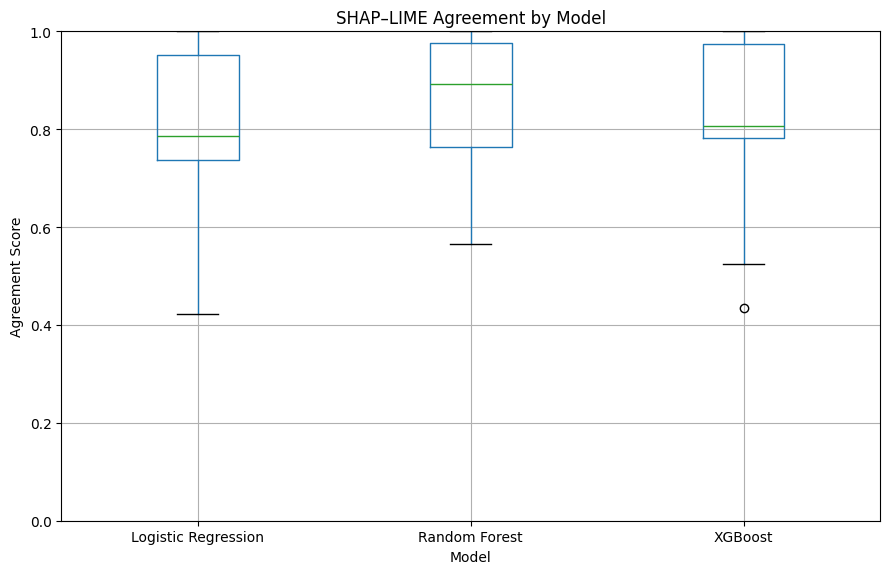

In [142]:
agreement_all.boxplot(
    column="Agreement_Score",
    by="Model",
    figsize=(9, 6)
)

plt.title("SHAP–LIME Agreement by Model")
plt.suptitle("")
plt.xlabel("Model")
plt.ylabel("Agreement Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

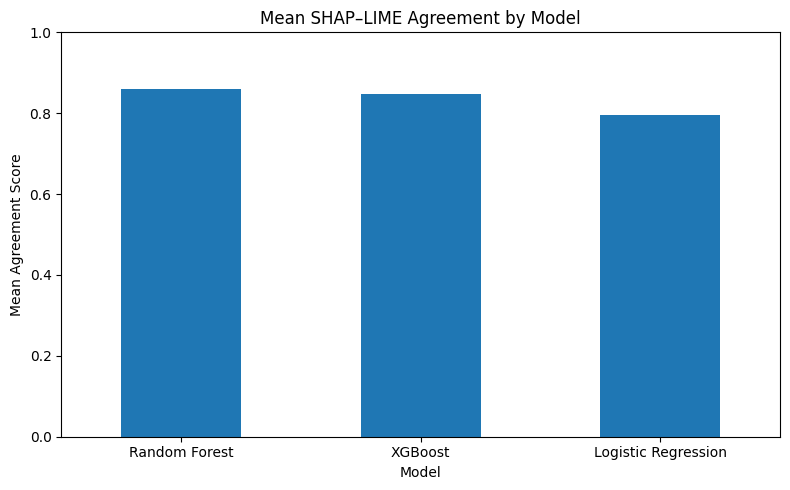

In [143]:
mean_agreement = (
    agreement_all
    .groupby("Model")["Agreement_Score"]
    .mean()
    .sort_values(ascending=False)
)

mean_agreement.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Mean SHAP–LIME Agreement by Model")
plt.xlabel("Model")
plt.ylabel("Mean Agreement Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [144]:
lowest_agreement_cases = (
    agreement_all
    .sort_values("Agreement_Score")
    .head(10)
)

lowest_agreement_cases[
    [
        "Model",
        "Patient_Position",
        "Original_Row_Index",
        "Spearman_Raw",
        "Top_3_Overlap",
        "Agreement_Score",
        "SHAP_Top_Features",
        "LIME_Top_Features"
    ]
]

,Model,Patient_Position,Original_Row_Index,Spearman_Raw,Top_3_Overlap,Agreement_Score,SHAP_Top_Features,LIME_Top_Features
43,Logistic Regression,43,264,0.023810,0.333333,0.422619,"Glucose, DiabetesPedigreeFunction, SkinThickness","Glucose, BMI, Pregnancies"
127,Logistic Regression,127,699,0.047619,0.333333,0.428571,"BMI, DiabetesPedigreeFunction, Age","Glucose, BMI, Pregnancies"
119,Logistic Regression,119,347,0.071429,0.333333,0.434524,"BMI, BloodPressure, Age","Glucose, BMI, Pregnancies"
347,XGBoost,39,345,0.071429,0.333333,0.434524,"Age, Pregnancies, BMI","Glucose, BMI, DiabetesPedigreeFunction"
49,Logistic Regression,49,535,0.190476,0.333333,0.464286,"BloodPressure, Glucose, Age","Glucose, BMI, Pregnancies"
115,Logistic Regression,115,127,0.285714,0.333333,0.488095,"Pregnancies, Age, DiabetesPedigreeFunction","Glucose, BMI, Pregnancies"
112,Logistic Regression,112,584,0.285714,0.333333,0.488095,"Pregnancies, Age, Insulin","Glucose, BMI, Pregnancies"
147,Logistic Regression,147,115,0.333333,0.333333,0.500000,"Glucose, Age, BloodPressure","Glucose, BMI, Pregnancies"
21,Logistic Regression,21,13,0.357143,0.333333,0.505952,"Glucose, Age, Insulin","Glucose, BMI, Pregnancies"
110,Logistic Regression,110,144,0.357143,0.333333,0.505952,"Glucose, Age, DiabetesPedigreeFunction","Glucose, BMI, Pregnancies"


In [145]:
highest_agreement_cases = (
    agreement_all
    .sort_values("Agreement_Score", ascending=False)
    .head(10)
)

highest_agreement_cases[
    [
        "Model",
        "Patient_Position",
        "Original_Row_Index",
        "Spearman_Raw",
        "Top_3_Overlap",
        "Agreement_Score",
        "SHAP_Top_Features",
        "LIME_Top_Features"
    ]
]

,Model,Patient_Position,Original_Row_Index,Spearman_Raw,Top_3_Overlap,Agreement_Score,SHAP_Top_Features,LIME_Top_Features
284,Random Forest,130,554,1.00000,1.0,1.000000,"Glucose, BMI, Age","Glucose, BMI, Age"
297,Random Forest,143,75,1.00000,1.0,1.000000,"Glucose, BMI, Age","Glucose, BMI, Age"
220,Random Forest,66,332,1.00000,1.0,1.000000,"Glucose, BMI, Age","Glucose, BMI, Age"
143,Logistic Regression,143,75,1.00000,1.0,1.000000,"Glucose, BMI, Pregnancies","Glucose, BMI, Pregnancies"
243,Random Forest,89,162,1.00000,1.0,1.000000,"Glucose, BMI, Age","Glucose, BMI, Age"
223,Random Forest,69,743,1.00000,1.0,1.000000,"Glucose, BMI, Age","Glucose, BMI, Age"
360,XGBoost,52,428,1.00000,1.0,1.000000,"Glucose, BMI, Age","Glucose, BMI, Age"
280,Random Forest,126,417,0.97619,1.0,0.994048,"Glucose, BMI, Age","Glucose, BMI, Age"
64,Logistic Regression,64,650,0.97619,1.0,0.994048,"Glucose, BMI, Pregnancies","Glucose, BMI, Pregnancies"
46,Logistic Regression,46,276,0.97619,1.0,0.994048,"BMI, Glucose, Pregnancies","Glucose, BMI, Pregnancies"


In [180]:
# Number of perturbed versions generated for each patient
N_PERTURBATIONS = 20

# Noise strength as a proportion of the training-set standard deviation
NOISE_LEVEL = 0.10

# Number of important features used for top-k overlap
TOP_K = 3

# LIME neighbourhood size
LIME_NUM_SAMPLES = 5000

# Reproducibility seed
RANDOM_STATE = 42

In [181]:
non_negative_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

In [182]:
integer_features = ["Pregnancies"]

In [183]:
train_feature_std = X_train_df.std(ddof=0)
train_feature_min = X_train_df.min()
train_feature_max = X_train_df.max()

perturbation_statistics = pd.DataFrame({
    "Feature": feature_names,
    "Training_Std": train_feature_std[feature_names].values,
    "Noise_Std": (
        NOISE_LEVEL * train_feature_std[feature_names]
    ).values,
    "Training_Min": train_feature_min[feature_names].values,
    "Training_Max": train_feature_max[feature_names].values
})

display(perturbation_statistics)

,Feature,Training_Std,Noise_Std,Training_Min,Training_Max
0,Pregnancies,3.311448,0.331145,0.000,17.000
1,Glucose,31.535381,3.153538,0.000,199.000
2,BloodPressure,18.387589,1.838759,0.000,122.000
3,SkinThickness,15.843516,1.584352,0.000,99.000
4,Insulin,107.648803,10.764880,0.000,744.000
5,BMI,7.854960,0.785496,0.000,67.100
6,DiabetesPedigreeFunction,0.330031,0.033003,0.084,2.329
7,Age,11.823798,1.182380,21.000,81.000


In [184]:
def generate_perturbed_patients(
    patient,
    training_std,
    training_min,
    training_max,
    n_perturbations=10,
    noise_level=0.05,
    random_state=42
):
    """
    Generate slightly perturbed versions of one patient.

    Parameters
    ----------
    patient : pandas Series
        Original patient in the unscaled clinical feature space.

    training_std : pandas Series
        Feature standard deviations calculated from the training set.

    training_min : pandas Series
        Minimum values from the training set.

    training_max : pandas Series
        Maximum values from the training set.

    n_perturbations : int
        Number of perturbed patients to generate.

    noise_level : float
        Noise scale as a proportion of each feature's training standard
        deviation.

    random_state : int
        Seed used for reproducibility.

    Returns
    -------
    pandas DataFrame
        Perturbed patients in the original unscaled feature space.
    """

    rng = np.random.default_rng(random_state)

    patient = patient[feature_names].astype(float)

    # Feature-specific noise standard deviations
    noise_std = (
        training_std[feature_names].values
        * noise_level
    )

    # Generate Gaussian noise
    noise = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=(n_perturbations, len(feature_names))
    )

    # Add the noise to the original patient
    perturbed_values = patient.values + noise

    perturbed_df = pd.DataFrame(
        perturbed_values,
        columns=feature_names
    )

    # Restrict perturbed values to ranges observed in training data
    for feature in feature_names:
        perturbed_df[feature] = perturbed_df[feature].clip(
            lower=training_min[feature],
            upper=training_max[feature]
        )

    # Pregnancies represents a count
    perturbed_df["Pregnancies"] = (
        perturbed_df["Pregnancies"]
        .round()
        .astype(int)
    )

    return perturbed_df

In [185]:
patient_index = 0

example_perturbations = generate_perturbed_patients(
    patient=X_test_df.iloc[patient_index],
    training_std=train_feature_std,
    training_min=train_feature_min,
    training_max=train_feature_max,
    n_perturbations=N_PERTURBATIONS,
    noise_level=NOISE_LEVEL,
    random_state=RANDOM_STATE
)

display(example_perturbations)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,7,155.720370,65.379899,1.490185,0.000000,26.377143,0.298219,39.626081
1,7,156.309893,65.617001,1.232296,0.710813,28.285443,0.309429,38.983990
2,7,155.976127,65.615258,0.000000,0.000000,26.865133,0.334348,39.817287
3,7,157.889533,64.978788,0.578992,4.443017,27.738408,0.364681,39.519463
4,7,156.433737,65.132638,1.788689,0.000000,26.740060,0.266790,40.769248
5,7,160.712858,62.776288,0.367825,1.256109,27.571779,0.322760,40.264375
6,7,159.213113,64.531621,1.000182,0.000000,27.148900,0.278476,39.244604
7,7,163.714354,62.407945,1.534093,0.000000,27.136949,0.299371,40.693137
8,7,161.501851,63.358779,0.000000,9.236008,27.249731,0.251898,38.660024
9,7,160.567815,64.261887,1.093972,0.000000,27.524532,0.314646,39.634235


In [186]:
comparison_example = pd.concat(
    [
        X_test_df.iloc[[patient_index]].assign(
            Version="Original"
        ),
        example_perturbations.assign(
            Version=[
                f"Perturbation_{i + 1}"
                for i in range(len(example_perturbations))
            ]
        )
    ],
    ignore_index=True
)

display(comparison_example)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Version
0,7,159.000000,64.000000,0.000000,0.000000,27.400000,0.294000,40.000000,Original
1,7,155.720370,65.379899,1.490185,0.000000,26.377143,0.298219,39.626081,Perturbation_1
2,7,156.309893,65.617001,1.232296,0.710813,28.285443,0.309429,38.983990,Perturbation_2
3,7,155.976127,65.615258,0.000000,0.000000,26.865133,0.334348,39.817287,Perturbation_3
4,7,157.889533,64.978788,0.578992,4.443017,27.738408,0.364681,39.519463,Perturbation_4
5,7,156.433737,65.132638,1.788689,0.000000,26.740060,0.266790,40.769248,Perturbation_5
6,7,160.712858,62.776288,0.367825,1.256109,27.571779,0.322760,40.264375,Perturbation_6
7,7,159.213113,64.531621,1.000182,0.000000,27.148900,0.278476,39.244604,Perturbation_7
8,7,163.714354,62.407945,1.534093,0.000000,27.136949,0.299371,40.693137,Perturbation_8
9,7,161.501851,63.358779,0.000000,9.236008,27.249731,0.251898,38.660024,Perturbation_9


In [187]:
def calculate_stability_spearman(
    original_explanation,
    perturbed_explanation
):
    """
    Compare the feature-importance rankings of two explanations.
    """

    original_importance = np.abs(
        np.asarray(original_explanation, dtype=float)
    )

    perturbed_importance = np.abs(
        np.asarray(perturbed_explanation, dtype=float)
    )

    correlation, _ = spearmanr(
        original_importance,
        perturbed_importance
    )

    # This can occur when one vector contains identical values
    if np.isnan(correlation):
        correlation = 0.0

    return float(correlation)

In [188]:
def normalise_spearman(correlation):
    """
    Convert Spearman correlation from [-1, 1] to [0, 1].
    """

    return (correlation + 1.0) / 2.0

In [189]:
def calculate_stability_top_k(
    original_explanation,
    perturbed_explanation,
    k=3
):
    """
    Measure overlap between the top-k features in the original and
    perturbed explanations.
    """

    original_importance = np.abs(
        np.asarray(original_explanation, dtype=float)
    )

    perturbed_importance = np.abs(
        np.asarray(perturbed_explanation, dtype=float)
    )

    if not 1 <= k <= len(original_importance):
        raise ValueError(
            f"k must be between 1 and {len(original_importance)}."
        )

    original_top_k = np.argsort(
        original_importance
    )[-k:]

    perturbed_top_k = np.argsort(
        perturbed_importance
    )[-k:]

    shared_features = set(original_top_k).intersection(
        set(perturbed_top_k)
    )

    return len(shared_features) / k

In [190]:
def calculate_explanation_similarity(
    original_explanation,
    perturbed_explanation,
    k=3,
    spearman_weight=0.5,
    top_k_weight=0.5
):
    """
    Calculate the similarity between an original explanation and one
    perturbed explanation.
    """

    if not np.isclose(
        spearman_weight + top_k_weight,
        1.0
    ):
        raise ValueError(
            "Spearman and top-k weights must sum to 1."
        )

    spearman_raw = calculate_stability_spearman(
        original_explanation,
        perturbed_explanation
    )

    spearman_normalised = normalise_spearman(
        spearman_raw
    )

    top_k_overlap = calculate_stability_top_k(
        original_explanation,
        perturbed_explanation,
        k=k
    )

    stability_score = (
        spearman_weight * spearman_normalised
        + top_k_weight * top_k_overlap
    )

    return {
        "spearman_raw": spearman_raw,
        "spearman_normalised": spearman_normalised,
        "top_k_overlap": top_k_overlap,
        "stability_score": stability_score
    }

In [191]:
def get_positive_class_probabilities(
    model,
    X_model_input
):
    """
    Return predicted probabilities for class 1.
    """

    probabilities = model.predict_proba(
        X_model_input
    )[:, 1]

    return np.asarray(probabilities, dtype=float)

In [192]:
def generate_lr_shap_explanations(
    perturbed_raw_df,
    scaler,
    shap_explainer
):
    """
    Scale perturbed clinical values and generate Logistic Regression
    SHAP explanations.
    """

    perturbed_scaled = scaler.transform(
        perturbed_raw_df[feature_names]
    )

    perturbed_scaled_df = pd.DataFrame(
        perturbed_scaled,
        columns=feature_names,
        index=perturbed_raw_df.index
    )

    shap_output = shap_explainer(
        perturbed_scaled_df
    )

    shap_values = get_positive_class_shap_values(
        shap_output
    )

    return shap_values, perturbed_scaled_df

In [193]:
def generate_rf_shap_explanations(
    perturbed_raw_df,
    shap_explainer
):
    """
    Generate Random Forest SHAP explanations.
    """

    shap_output = shap_explainer(
        perturbed_raw_df[feature_names]
    )

    shap_values = get_positive_class_shap_values(
        shap_output
    )

    return shap_values

In [194]:
def generate_xgb_shap_explanations(
    perturbed_raw_df,
    model
):
    """
    Generate XGBoost SHAP values using XGBoost's native
    pred_contribs implementation.
    """

    xgb_matrix = xgb.DMatrix(
        perturbed_raw_df[feature_names],
        feature_names=feature_names
    )

    contributions = model.get_booster().predict(
        xgb_matrix,
        pred_contribs=True
    )

    # Remove the final bias/base-value column
    shap_values = contributions[:, :-1]

    return shap_values

In [195]:
def generate_lime_explanations_for_perturbations(
    explainer,
    model,
    X_model_input,
    n_features,
    label=1,
    num_samples=5000
):
    """
    Generate a LIME attribution vector for every perturbed patient.
    """

    lime_matrix = np.zeros(
        (len(X_model_input), n_features),
        dtype=float
    )

    for row_position in range(len(X_model_input)):

        if isinstance(X_model_input, pd.DataFrame):
            patient_values = (
                X_model_input.iloc[row_position].values
            )
        else:
            patient_values = np.asarray(
                X_model_input[row_position]
            )

        explanation = explainer.explain_instance(
            data_row=patient_values,
            predict_fn=model.predict_proba,
            labels=(label,),
            num_features=n_features,
            num_samples=num_samples
        )

        lime_matrix[row_position] = (
            lime_explanation_to_vector(
                explanation=explanation,
                n_features=n_features,
                label=label
            )
        )

    return lime_matrix

In [196]:
def summarise_patient_stability(
    original_explanation,
    perturbed_explanations,
    k=3
):
    """
    Compare one original explanation with all perturbed explanations
    and return the average stability metrics.
    """

    comparison_results = []

    for perturbation_index in range(
        len(perturbed_explanations)
    ):
        comparison = calculate_explanation_similarity(
            original_explanation=original_explanation,
            perturbed_explanation=(
                perturbed_explanations[
                    perturbation_index
                ]
            ),
            k=k
        )

        comparison_results.append(comparison)

    comparison_df = pd.DataFrame(
        comparison_results
    )

    return {
        "Mean_Stability_Spearman": (
            comparison_df["spearman_raw"].mean()
        ),
        "Std_Stability_Spearman": (
            comparison_df["spearman_raw"].std(ddof=0)
        ),
        "Mean_Stability_TopK": (
            comparison_df["top_k_overlap"].mean()
        ),
        "Std_Stability_TopK": (
            comparison_df["top_k_overlap"].std(ddof=0)
        ),
        "Mean_Stability_Score": (
            comparison_df["stability_score"].mean()
        ),
        "Std_Stability_Score": (
            comparison_df["stability_score"].std(ddof=0)
        ),
        "Minimum_Stability_Score": (
            comparison_df["stability_score"].min()
        ),
        "Maximum_Stability_Score": (
            comparison_df["stability_score"].max()
        )
    }

In [197]:
def calculate_lr_shap_stability(
    X_test_raw,
    original_shap_matrix,
    model,
    scaler,
    shap_explainer,
    n_perturbations=10,
    noise_level=0.05,
    k=3,
    random_state=42
):
    """
    Calculate patient-level SHAP stability for Logistic Regression.
    """

    results = []

    for patient_position in range(len(X_test_raw)):

        original_patient = X_test_raw.iloc[
            patient_position
        ]

        perturbed_raw = generate_perturbed_patients(
            patient=original_patient,
            training_std=train_feature_std,
            training_min=train_feature_min,
            training_max=train_feature_max,
            n_perturbations=n_perturbations,
            noise_level=noise_level,
            random_state=(
                random_state + patient_position
            )
        )

        perturbed_shap, perturbed_scaled = (
            generate_lr_shap_explanations(
                perturbed_raw_df=perturbed_raw,
                scaler=scaler,
                shap_explainer=shap_explainer
            )
        )

        stability = summarise_patient_stability(
            original_explanation=(
                original_shap_matrix[
                    patient_position
                ]
            ),
            perturbed_explanations=perturbed_shap,
            k=k
        )

        original_scaled = (
            X_test_scaled_df.iloc[
                [patient_position]
            ]
        )

        original_probability = (
            model.predict_proba(
                original_scaled
            )[0, 1]
        )

        perturbed_probabilities = (
            model.predict_proba(
                perturbed_scaled
            )[:, 1]
        )

        class_flip_rate = np.mean(
            (perturbed_probabilities >= 0.5)
            != (original_probability >= 0.5)
        )

        results.append({
            "Model": "Logistic Regression",
            "Explainer": "SHAP",
            "Patient_Position": patient_position,
            "Original_Row_Index": (
                X_test_raw.index[
                    patient_position
                ]
            ),
            "Original_Probability": (
                original_probability
            ),
            "Mean_Perturbed_Probability": (
                perturbed_probabilities.mean()
            ),
            "Mean_Absolute_Probability_Change": (
                np.mean(
                    np.abs(
                        perturbed_probabilities
                        - original_probability
                    )
                )
            ),
            "Class_Flip_Rate": class_flip_rate,
            **stability
        })

        if (patient_position + 1) % 20 == 0:
            print(
                "LR SHAP:",
                patient_position + 1,
                "/",
                len(X_test_raw)
            )

    return pd.DataFrame(results)

In [198]:
stability_lr_shap = calculate_lr_shap_stability(
    X_test_raw=X_test_df,
    original_shap_matrix=shap_values_lr,
    model=best_log_reg,
    scaler=scaler,
    shap_explainer=shap_explainer_lr,
    n_perturbations=N_PERTURBATIONS,
    noise_level=NOISE_LEVEL,
    k=TOP_K,
    random_state=RANDOM_STATE
)

stability_lr_shap.head()

C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR SHAP: 20 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR SHAP: 40 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR SHAP: 60 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR SHAP: 80 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR SHAP: 100 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR SHAP: 120 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR SHAP: 140 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

,Model,Explainer,Patient_Position,Original_Row_Index,Original_Probability,Mean_Perturbed_Probability,Mean_Absolute_Probability_Change,Class_Flip_Rate,Mean_Stability_Spearman,Std_Stability_Spearman,Mean_Stability_TopK,Std_Stability_TopK,Mean_Stability_Score,Std_Stability_Score,Minimum_Stability_Score,Maximum_Stability_Score
0,Logistic Regression,SHAP,0,44,0.714642,0.705950,0.016949,0.0,0.986905,0.011845,1.000000,0.000000,0.996726,0.002961,0.994048,1.0
1,Logistic Regression,SHAP,1,672,0.251080,0.247030,0.022675,0.0,0.958333,0.029999,0.833333,0.166667,0.906250,0.086870,0.809524,1.0
2,Logistic Regression,SHAP,2,700,0.426945,0.424111,0.016943,0.0,0.875000,0.112907,0.750000,0.144338,0.843750,0.087277,0.726190,1.0
3,Logistic Regression,SHAP,3,630,0.443559,0.441313,0.017321,0.0,0.882143,0.095082,0.983333,0.072648,0.962202,0.041122,0.815476,1.0
4,Logistic Regression,SHAP,4,81,0.012432,0.012588,0.001131,0.0,0.991667,0.017293,1.000000,0.000000,0.997917,0.004323,0.982143,1.0


In [199]:
def calculate_lr_lime_stability(
    X_test_raw,
    original_lime_matrix,
    model,
    scaler,
    lime_explainer,
    n_perturbations=10,
    noise_level=0.05,
    k=3,
    num_samples=5000,
    random_state=42
):
    """
    Calculate patient-level LIME stability for Logistic Regression.
    """

    results = []

    for patient_position in range(len(X_test_raw)):

        original_patient = X_test_raw.iloc[
            patient_position
        ]

        perturbed_raw = generate_perturbed_patients(
            patient=original_patient,
            training_std=train_feature_std,
            training_min=train_feature_min,
            training_max=train_feature_max,
            n_perturbations=n_perturbations,
            noise_level=noise_level,
            random_state=(
                random_state + patient_position
            )
        )

        perturbed_scaled = scaler.transform(
            perturbed_raw[feature_names]
        )

        perturbed_scaled_df = pd.DataFrame(
            perturbed_scaled,
            columns=feature_names
        )

        perturbed_lime = (
            generate_lime_explanations_for_perturbations(
                explainer=lime_explainer,
                model=model,
                X_model_input=perturbed_scaled_df,
                n_features=len(feature_names),
                label=1,
                num_samples=num_samples
            )
        )

        stability = summarise_patient_stability(
            original_explanation=(
                original_lime_matrix[
                    patient_position
                ]
            ),
            perturbed_explanations=perturbed_lime,
            k=k
        )

        original_probability = (
            model.predict_proba(
                X_test_scaled_df.iloc[
                    [patient_position]
                ]
            )[0, 1]
        )

        perturbed_probabilities = (
            model.predict_proba(
                perturbed_scaled_df
            )[:, 1]
        )

        class_flip_rate = np.mean(
            (perturbed_probabilities >= 0.5)
            != (original_probability >= 0.5)
        )

        results.append({
            "Model": "Logistic Regression",
            "Explainer": "LIME",
            "Patient_Position": patient_position,
            "Original_Row_Index": (
                X_test_raw.index[
                    patient_position
                ]
            ),
            "Original_Probability": (
                original_probability
            ),
            "Mean_Perturbed_Probability": (
                perturbed_probabilities.mean()
            ),
            "Mean_Absolute_Probability_Change": (
                np.mean(
                    np.abs(
                        perturbed_probabilities
                        - original_probability
                    )
                )
            ),
            "Class_Flip_Rate": class_flip_rate,
            **stability
        })

        if (patient_position + 1) % 10 == 0:
            print(
                "LR LIME:",
                patient_position + 1,
                "/",
                len(X_test_raw)
            )

    return pd.DataFrame(results)

In [200]:
stability_lr_lime = calculate_lr_lime_stability(
    X_test_raw=X_test_df,
    original_lime_matrix=lime_values_lr,
    model=best_log_reg,
    scaler=scaler,
    lime_explainer=lime_explainer_lr,
    n_perturbations=N_PERTURBATIONS,
    noise_level=NOISE_LEVEL,
    k=TOP_K,
    num_samples=LIME_NUM_SAMPLES,
    random_state=RANDOM_STATE
)

stability_lr_lime.head()

C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 10 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 20 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 30 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 40 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 50 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 60 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 70 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 80 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 90 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 100 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 110 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 120 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 130 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 140 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

LR LIME: 150 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X ha

,Model,Explainer,Patient_Position,Original_Row_Index,Original_Probability,Mean_Perturbed_Probability,Mean_Absolute_Probability_Change,Class_Flip_Rate,Mean_Stability_Spearman,Std_Stability_Spearman,Mean_Stability_TopK,Std_Stability_TopK,Mean_Stability_Score,Std_Stability_Score,Minimum_Stability_Score,Maximum_Stability_Score
0,Logistic Regression,LIME,0,44,0.714642,0.705950,0.016949,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
1,Logistic Regression,LIME,1,672,0.251080,0.247030,0.022675,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
2,Logistic Regression,LIME,2,700,0.426945,0.424111,0.016943,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
3,Logistic Regression,LIME,3,630,0.443559,0.441313,0.017321,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
4,Logistic Regression,LIME,4,81,0.012432,0.012588,0.001131,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0


In [201]:
def calculate_tree_shap_stability(
    X_test_raw,
    original_shap_matrix,
    model,
    model_name,
    shap_generator,
    n_perturbations=10,
    noise_level=0.05,
    k=3,
    random_state=42
):
    """
    Calculate SHAP stability for Random Forest or XGBoost.
    """

    results = []

    for patient_position in range(len(X_test_raw)):

        original_patient = X_test_raw.iloc[
            patient_position
        ]

        perturbed_raw = generate_perturbed_patients(
            patient=original_patient,
            training_std=train_feature_std,
            training_min=train_feature_min,
            training_max=train_feature_max,
            n_perturbations=n_perturbations,
            noise_level=noise_level,
            random_state=(
                random_state + patient_position
            )
        )

        perturbed_shap = shap_generator(
            perturbed_raw
        )

        stability = summarise_patient_stability(
            original_explanation=(
                original_shap_matrix[
                    patient_position
                ]
            ),
            perturbed_explanations=perturbed_shap,
            k=k
        )

        original_probability = (
            model.predict_proba(
                X_test_raw.iloc[
                    [patient_position]
                ]
            )[0, 1]
        )

        perturbed_probabilities = (
            model.predict_proba(
                perturbed_raw
            )[:, 1]
        )

        class_flip_rate = np.mean(
            (perturbed_probabilities >= 0.5)
            != (original_probability >= 0.5)
        )

        results.append({
            "Model": model_name,
            "Explainer": "SHAP",
            "Patient_Position": patient_position,
            "Original_Row_Index": (
                X_test_raw.index[
                    patient_position
                ]
            ),
            "Original_Probability": (
                original_probability
            ),
            "Mean_Perturbed_Probability": (
                perturbed_probabilities.mean()
            ),
            "Mean_Absolute_Probability_Change": (
                np.mean(
                    np.abs(
                        perturbed_probabilities
                        - original_probability
                    )
                )
            ),
            "Class_Flip_Rate": class_flip_rate,
            **stability
        })

        if (patient_position + 1) % 20 == 0:
            print(
                model_name,
                "SHAP:",
                patient_position + 1,
                "/",
                len(X_test_raw)
            )

    return pd.DataFrame(results)

In [202]:
def rf_shap_generator(X_perturbed):
    shap_output = shap_explainer_rf(
        X_perturbed[feature_names]
    )

    return get_positive_class_shap_values(
        shap_output
    )

In [203]:
stability_rf_shap = calculate_tree_shap_stability(
    X_test_raw=X_test_df,
    original_shap_matrix=shap_values_rf,
    model=best_rf,
    model_name="Random Forest",
    shap_generator=rf_shap_generator,
    n_perturbations=N_PERTURBATIONS,
    noise_level=NOISE_LEVEL,
    k=TOP_K,
    random_state=RANDOM_STATE
)
stability_rf_shap.head()

Random Forest SHAP: 20 / 154
Random Forest SHAP: 40 / 154
Random Forest SHAP: 60 / 154
Random Forest SHAP: 80 / 154
Random Forest SHAP: 100 / 154
Random Forest SHAP: 120 / 154
Random Forest SHAP: 140 / 154


,Model,Explainer,Patient_Position,Original_Row_Index,Original_Probability,Mean_Perturbed_Probability,Mean_Absolute_Probability_Change,Class_Flip_Rate,Mean_Stability_Spearman,Std_Stability_Spearman,Mean_Stability_TopK,Std_Stability_TopK,Mean_Stability_Score,Std_Stability_Score,Minimum_Stability_Score,Maximum_Stability_Score
0,Random Forest,SHAP,0,44,0.770622,0.756857,0.034805,0.00,0.954762,0.044480,1.000000,0.000000,0.988690,0.011120,0.958333,1.000000
1,Random Forest,SHAP,1,672,0.235266,0.227941,0.010687,0.00,0.982143,0.021129,0.833333,0.166667,0.912202,0.087277,0.815476,1.000000
2,Random Forest,SHAP,2,700,0.163117,0.228038,0.065912,0.00,0.898810,0.106712,0.983333,0.072648,0.966369,0.059947,0.714286,1.000000
3,Random Forest,SHAP,3,630,0.377581,0.353263,0.118381,0.25,0.898810,0.084808,0.950000,0.119024,0.949702,0.074190,0.750000,0.994048
4,Random Forest,SHAP,4,81,0.051401,0.054207,0.003354,0.00,0.995238,0.016148,1.000000,0.000000,0.998810,0.004037,0.982143,1.000000


In [204]:
def xgb_shap_generator(X_perturbed):
    return generate_xgb_shap_explanations(
        perturbed_raw_df=X_perturbed,
        model=best_xgb
    )

In [205]:
stability_xgb_shap = calculate_tree_shap_stability(
    X_test_raw=X_test_df,
    original_shap_matrix=shap_values_xgb,
    model=best_xgb,
    model_name="XGBoost",
    shap_generator=xgb_shap_generator,
    n_perturbations=N_PERTURBATIONS,
    noise_level=NOISE_LEVEL,
    k=TOP_K,
    random_state=RANDOM_STATE
)

XGBoost SHAP: 20 / 154
XGBoost SHAP: 40 / 154
XGBoost SHAP: 60 / 154
XGBoost SHAP: 80 / 154
XGBoost SHAP: 100 / 154
XGBoost SHAP: 120 / 154
XGBoost SHAP: 140 / 154


In [206]:
def calculate_tree_lime_stability(
    X_test_raw,
    original_lime_matrix,
    model,
    model_name,
    lime_explainer,
    n_perturbations=10,
    noise_level=0.05,
    k=3,
    num_samples=5000,
    random_state=42
):
    """
    Calculate LIME stability for Random Forest or XGBoost.
    """

    results = []

    for patient_position in range(len(X_test_raw)):

        original_patient = X_test_raw.iloc[
            patient_position
        ]

        perturbed_raw = generate_perturbed_patients(
            patient=original_patient,
            training_std=train_feature_std,
            training_min=train_feature_min,
            training_max=train_feature_max,
            n_perturbations=n_perturbations,
            noise_level=noise_level,
            random_state=(
                random_state + patient_position
            )
        )

        perturbed_lime = (
            generate_lime_explanations_for_perturbations(
                explainer=lime_explainer,
                model=model,
                X_model_input=perturbed_raw,
                n_features=len(feature_names),
                label=1,
                num_samples=num_samples
            )
        )

        stability = summarise_patient_stability(
            original_explanation=(
                original_lime_matrix[
                    patient_position
                ]
            ),
            perturbed_explanations=perturbed_lime,
            k=k
        )

        original_probability = (
            model.predict_proba(
                X_test_raw.iloc[
                    [patient_position]
                ]
            )[0, 1]
        )

        perturbed_probabilities = (
            model.predict_proba(
                perturbed_raw
            )[:, 1]
        )

        class_flip_rate = np.mean(
            (perturbed_probabilities >= 0.5)
            != (original_probability >= 0.5)
        )

        results.append({
            "Model": model_name,
            "Explainer": "LIME",
            "Patient_Position": patient_position,
            "Original_Row_Index": (
                X_test_raw.index[
                    patient_position
                ]
            ),
            "Original_Probability": (
                original_probability
            ),
            "Mean_Perturbed_Probability": (
                perturbed_probabilities.mean()
            ),
            "Mean_Absolute_Probability_Change": (
                np.mean(
                    np.abs(
                        perturbed_probabilities
                        - original_probability
                    )
                )
            ),
            "Class_Flip_Rate": class_flip_rate,
            **stability
        })

        if (patient_position + 1) % 10 == 0:
            print(
                model_name,
                "LIME:",
                patient_position + 1,
                "/",
                len(X_test_raw)
            )

    return pd.DataFrame(results)

In [207]:
stability_rf_lime = calculate_tree_lime_stability(
    X_test_raw=X_test_df,
    original_lime_matrix=lime_values_rf,
    model=best_rf,
    model_name="Random Forest",
    lime_explainer=lime_explainer_tree,
    n_perturbations=N_PERTURBATIONS,
    noise_level=NOISE_LEVEL,
    k=TOP_K,
    num_samples=LIME_NUM_SAMPLES,
    random_state=RANDOM_STATE
)

C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 10 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 20 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 30 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 40 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 50 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 60 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 70 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 80 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 90 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 100 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 110 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 120 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 130 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 140 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

Random Forest LIME: 150 / 154


C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Imad Khan\AppData\Local\Programs\Python\Python310\l

In [ ]:
stability_xgb_lime = calculate_tree_lime_stability(
    X_test_raw=X_test_df,
    original_lime_matrix=lime_values_xgb,
    model=best_xgb,
    model_name="XGBoost",
    lime_explainer=lime_explainer_tree,
    n_perturbations=N_PERTURBATIONS,
    noise_level=NOISE_LEVEL,
    k=TOP_K,
    num_samples=LIME_NUM_SAMPLES,
    random_state=RANDOM_STATE
)

XGBoost LIME: 10 / 154
XGBoost LIME: 20 / 154
XGBoost LIME: 30 / 154
XGBoost LIME: 40 / 154
XGBoost LIME: 50 / 154
XGBoost LIME: 60 / 154
XGBoost LIME: 70 / 154
XGBoost LIME: 80 / 154
XGBoost LIME: 90 / 154
XGBoost LIME: 100 / 154
XGBoost LIME: 110 / 154
XGBoost LIME: 120 / 154
XGBoost LIME: 130 / 154
XGBoost LIME: 140 / 154
XGBoost LIME: 150 / 154


In [178]:
stability_all = pd.concat(
    [
        stability_lr_shap,
        stability_lr_lime,
        stability_rf_shap,
        stability_rf_lime,
        stability_xgb_shap,
        stability_xgb_lime
    ],
    ignore_index=True
)

print("Combined stability shape:", stability_all.shape)

stability_all.head()

Combined stability shape: (924, 16)


,Model,Explainer,Patient_Position,Original_Row_Index,Original_Probability,Mean_Perturbed_Probability,Mean_Absolute_Probability_Change,Class_Flip_Rate,Mean_Stability_Spearman,Std_Stability_Spearman,Mean_Stability_TopK,Std_Stability_TopK,Mean_Stability_Score,Std_Stability_Score,Minimum_Stability_Score,Maximum_Stability_Score
0,Logistic Regression,SHAP,0,44,0.714642,0.712892,0.009134,0.0,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.0
1,Logistic Regression,SHAP,1,672,0.251080,0.253088,0.009968,0.0,0.969048,0.015246,0.866667,0.163299,0.925595,0.081495,0.821429,1.0
2,Logistic Regression,SHAP,2,700,0.426945,0.422699,0.007838,0.0,0.957143,0.067175,0.800000,0.163299,0.889286,0.090437,0.773810,1.0
3,Logistic Regression,SHAP,3,630,0.443559,0.440851,0.009126,0.0,0.978571,0.019778,1.000000,0.000000,0.994643,0.004944,0.982143,1.0
4,Logistic Regression,SHAP,4,81,0.012432,0.012315,0.000577,0.0,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.0


In [179]:
stability_summary = (
    stability_all
    .groupby(["Model", "Explainer"])
    .agg(
        Mean_Spearman=(
            "Mean_Stability_Spearman",
            "mean"
        ),
        Median_Spearman=(
            "Mean_Stability_Spearman",
            "median"
        ),
        Mean_Top3_Overlap=(
            "Mean_Stability_TopK",
            "mean"
        ),
        Median_Top3_Overlap=(
            "Mean_Stability_TopK",
            "median"
        ),
        Mean_Stability=(
            "Mean_Stability_Score",
            "mean"
        ),
        Median_Stability=(
            "Mean_Stability_Score",
            "median"
        ),
        Std_Stability=(
            "Mean_Stability_Score",
            "std"
        ),
        Minimum_Stability=(
            "Mean_Stability_Score",
            "min"
        ),
        Maximum_Stability=(
            "Mean_Stability_Score",
            "max"
        ),
        Mean_Class_Flip_Rate=(
            "Class_Flip_Rate",
            "mean"
        ),
        Mean_Probability_Change=(
            "Mean_Absolute_Probability_Change",
            "mean"
        )
    )
    .round(4)
    .reset_index()
)

display(stability_summary)

,Model,Explainer,Mean_Spearman,Median_Spearman,Mean_Top3_Overlap,Median_Top3_Overlap,Mean_Stability,Median_Stability,Std_Stability,Minimum_Stability,Maximum_Stability,Mean_Class_Flip_Rate,Mean_Probability_Change
0,Logistic Regression,LIME,0.9998,1.0000,1.0000,1.0,0.9999,1.0000,0.0004,0.9958,1.0,0.0136,0.0082
1,Logistic Regression,SHAP,0.9775,0.9833,0.9699,1.0,0.9793,0.9940,0.0292,0.8756,1.0,0.0136,0.0082
2,Random Forest,LIME,0.9841,0.9905,0.9898,1.0,0.9909,0.9970,0.0198,0.8786,1.0,0.0234,0.0156
3,Random Forest,SHAP,0.9590,0.9750,0.9481,1.0,0.9638,0.9866,0.0435,0.7905,1.0,0.0234,0.0156
4,XGBoost,LIME,0.9840,0.9881,0.9766,1.0,0.9843,0.9964,0.0377,0.8071,1.0,0.0149,0.0122
5,XGBoost,SHAP,0.9772,0.9857,0.9604,1.0,0.9745,0.9946,0.0379,0.8399,1.0,0.0149,0.0122
